In [10]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import cv2

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

In [2]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [7]:
bpe_path = f"/data3/rikhat.akizhanov/human_global_motion/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(
    bpe_path=bpe_path,
    load_from_HF=False,
    checkpoint_path="/data3/rikhat.akizhanov/human_global_motion/data/sam3-checkpoints/sam3.pt"
    )

processor = Sam3Processor(model, confidence_threshold=0.5)

In [9]:
dataset_path = "/data3/rikhat.akizhanov/DECO/"

data_path = os.path.join(dataset_path, "datasets/Release_Datasets/damon", "hot_dca_trainval.npz")
data = np.load(data_path, allow_pickle=True)


dict_keys(['refrigerator', 'book', 'clock', 'vase', 'bottle', 'supporting'])
found 0 object(s)


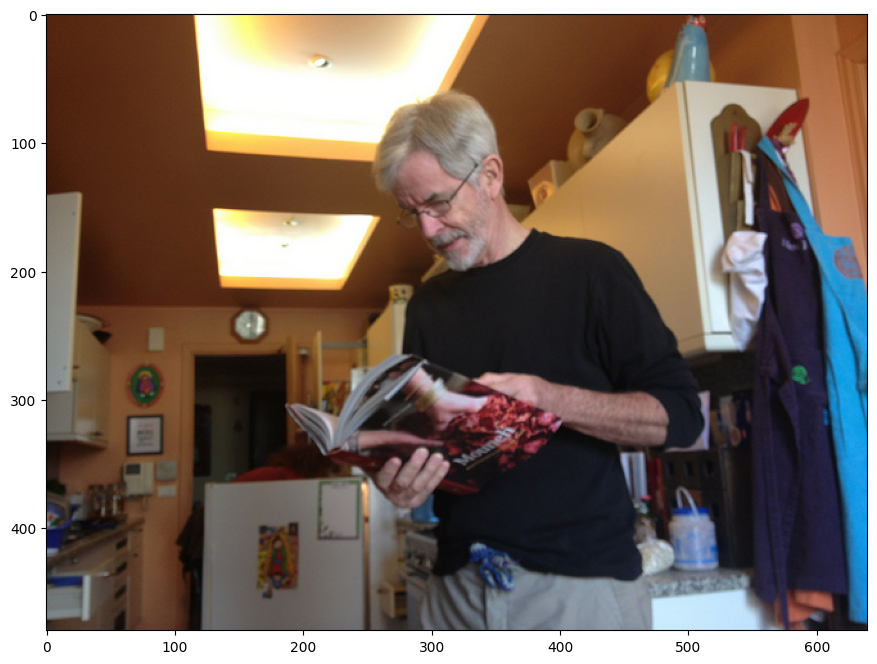

In [20]:
idx = 17

objects = data["contact_label_objectwise"][idx].keys()
print(objects)

img_path = os.path.join(dataset_path, data["imgname"][idx])
img = Image.open(img_path)

inference_state = processor.set_image(img)
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="supporting")


img0 = Image.open(img_path)
plot_results(img0, inference_state)